# 01 EDA

Notebook nay kiem tra schema, chat luong du lieu va tong quan doanh so.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_params
from src.data import load_raw_data, clean_sales_data, schema_snapshot
from src.features import build_weekly_sales

config = load_params()
raw_df = load_raw_data(config, PROJECT_ROOT)
clean_df, cleaning_report = clean_sales_data(raw_df, config)
schema_df = schema_snapshot(raw_df)
weekly_sales = build_weekly_sales(clean_df, frequency=config['forecasting']['frequency'])
schema_df.head(10)


,column,dtype,missing_count,missing_pct
0,Postal Code,float64,11,0.11
1,Row ID,int64,0,0.00
2,Order ID,str,0,0.00
3,Order Date,str,0,0.00
4,Ship Mode,str,0,0.00
5,Ship Date,str,0,0.00
6,Customer Name,str,0,0.00
7,Segment,str,0,0.00
8,Country,str,0,0.00
9,Customer ID,str,0,0.00


In [2]:
print('Raw shape:', raw_df.shape)
print('Clean shape:', clean_df.shape)
print('Cleaning report:', cleaning_report)
clean_df[['Order Date', 'Category', 'Sub-Category', 'Sales']].head()


Raw shape: (9800, 18)
Clean shape: (9800, 22)
Cleaning report: {'raw_rows': 9800, 'duplicate_rows_removed': 0, 'invalid_date_rows': 0, 'missing_core_rows': 0, 'final_rows': 9800, 'optional_columns_available': [], 'optional_columns_missing': ['Quantity', 'Discount', 'Profit']}


,Order Date,Category,Sub-Category,Sales
0,2017-11-08,Furniture,Bookcases,261.9600
1,2017-11-08,Furniture,Chairs,731.9400
2,2017-06-12,Office Supplies,Labels,14.6200
3,2016-10-11,Furniture,Tables,957.5775
4,2016-10-11,Office Supplies,Storage,22.3680


In [3]:
print('Weekly sales tail')
weekly_sales[['ds', 'y']].tail(12)


Weekly sales tail


,ds,y
36,2018-01-01,43476.4740
37,2018-02-01,19920.9974
38,2018-03-01,58863.4128
39,2018-04-01,35541.9101
40,2018-05-01,43825.9822
41,2018-06-01,48190.7277
42,2018-07-01,44825.1040
43,2018-08-01,62837.8480
44,2018-09-01,86152.8880
45,2018-10-01,77448.1312



Top sub-categories by sales


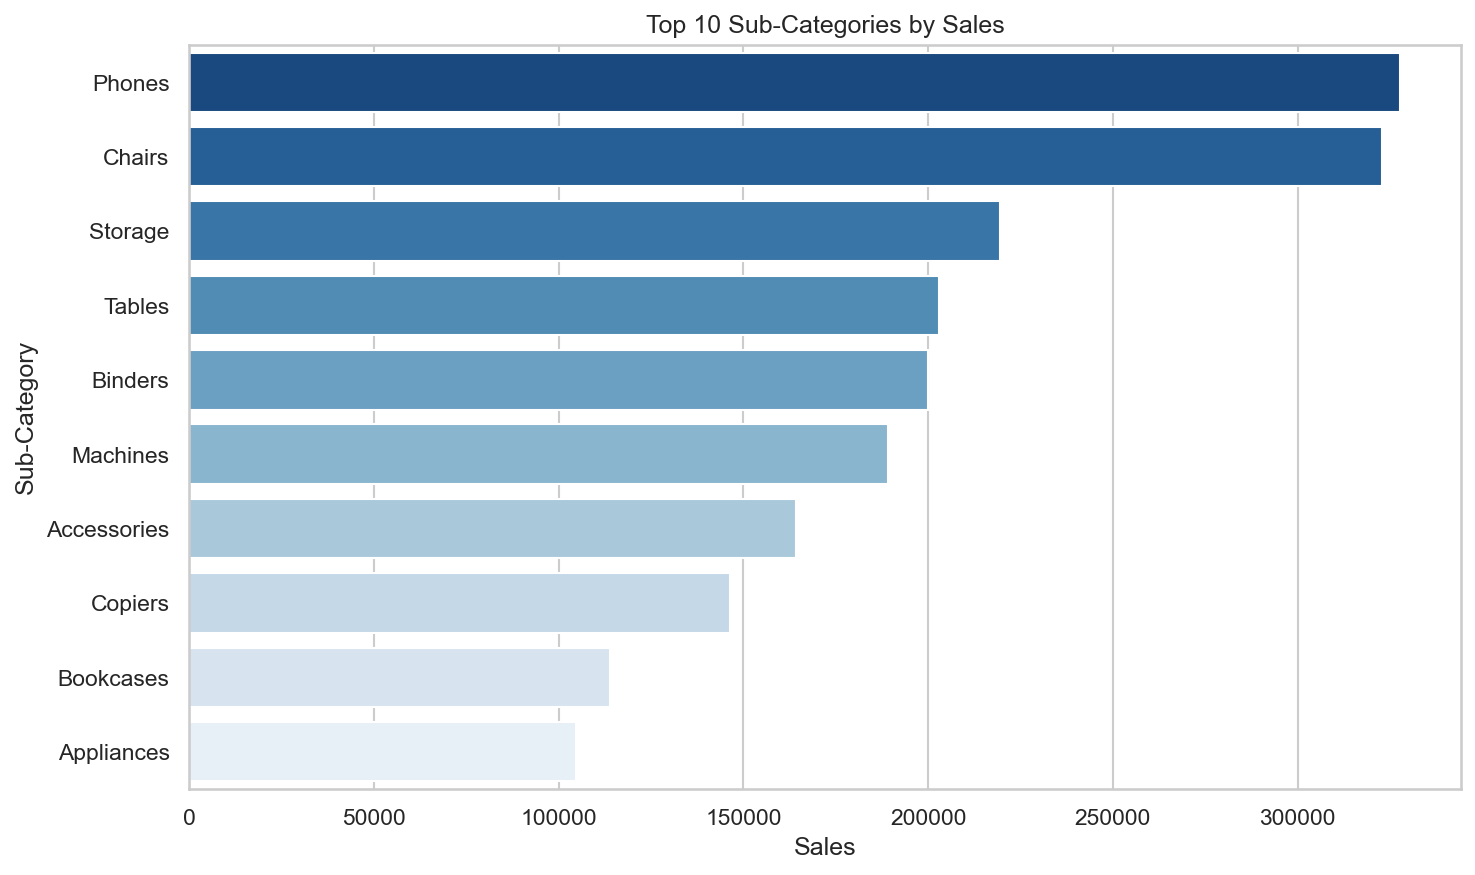


Sales over time


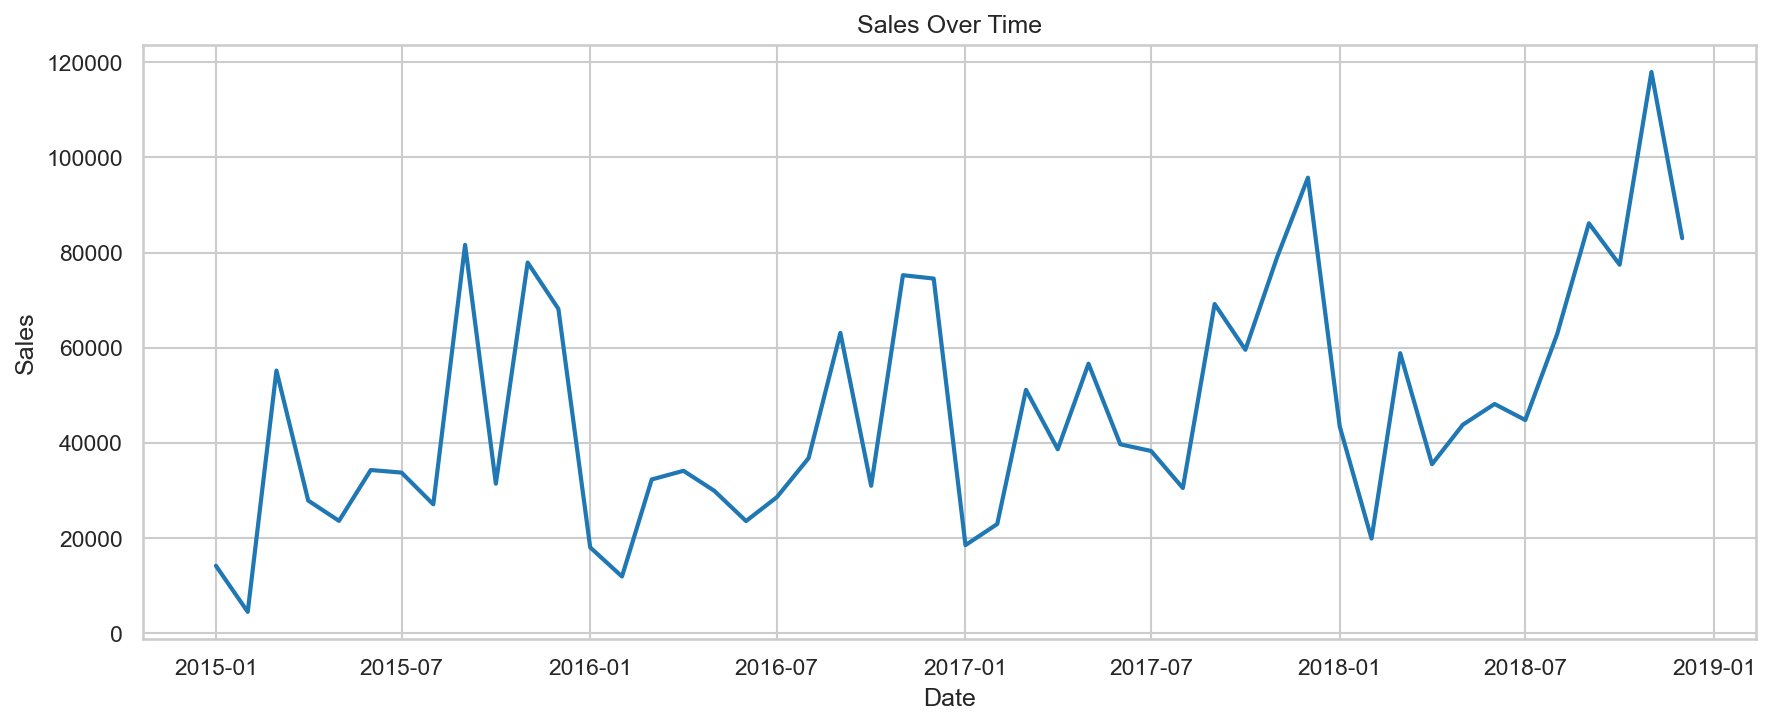

In [4]:
figures_dir = PROJECT_ROOT / 'outputs' / 'figures'
for title, filename in [
    ('Top sub-categories by sales', 'top_subcategories.png'),
    ('Sales over time', 'weekly_sales.png'),
]:
    path = figures_dir / filename
    print(f'\n{title}')
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'Missing figure: {path}')
